# Titanic: Machine Learning from Disaster
## Exploratory Data Analysis (EDA) & Data Cleaning
**Internship Task:** Level 1 - Explore the classic Titanic dataset using Python
**Goal:** Perform data cleaning, generate summary statistics, and visualize patterns.

### Step 1: Loading the Dataset
We are using the `pandas` library to load the training data provided by Kaggle

In [57]:
import pandas as pd
train_df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
print(train_df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


### Step 2: Data Cleaning - Identifying Missing Values
To "clean and organize" the data, we first need to identify gaps. 

##### Identifying Gaps in the Data
Before we can clean the dataset, we need to see which columns are incomplete. 
We use `.isnull().sum()` to count the missing entries for each feature.

In [58]:
# Count missing values for each column
missing_data = train_df.isnull().sum()
print(missing_data[missing_data > 0]) # Only show columns that have missing values

Age         177
Cabin       687
Embarked      2
dtype: int64


Common missing values in this dataset include **Age**, **Cabin**, and **Embarked**.

### Step 3: Data Cleaning- Handling Missing Values
We will now handle the missing data identified in the previous step:
1. **Age**: Fill missing values with the **median** (more robust than the mean).
2. **Embarked**: Fill the 2 missing values with the **mode** (most common port).
3. **Cabin**: Since ~77% is missing, we will **drop** this column as it lacks enough data for reliable insights.

In [59]:
# 1. Fill missing Age with the median
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())

# 2. Fill missing Embarked with the mode (S is usually the most common)
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

# 3. Drop the Cabin column
train_df.drop(columns=['Cabin'], inplace=True)

# 4. Verify cleaning
print("Missing values after cleaning:")
print(train_df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


### Step 4: Converting Categorical Types
To analyze correlations, we must convert the 'Sex' column from text to numerical values (0 for male, 1 for female).

In [60]:
# Convert Sex to 0 and 1
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})

# Show the first few rows to see the changes
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S


### Step 5: Summary Statistics
Before visualizing, we generate a statistical summary to understand the distribution of our numerical data (Age, Fare, Pclass, etc.).

In [61]:
# Detailed summary statistics for numerical columns
print("Numerical Summary:")
print(train_df.describe())

# Check the distribution of the target variable (Survived)
print("\nSurvival Count (0 = No, 1 = Yes):")
print(train_df['Survived'].value_counts())

Numerical Summary:
       PassengerId    Survived      Pclass         Sex         Age  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642    0.352413   29.361582   
std     257.353842    0.486592    0.836071    0.477990   13.019697   
min       1.000000    0.000000    1.000000    0.000000    0.420000   
25%     223.500000    0.000000    2.000000    0.000000   22.000000   
50%     446.000000    0.000000    3.000000    0.000000   28.000000   
75%     668.500000    1.000000    3.000000    1.000000   35.000000   
max     891.000000    1.000000    3.000000    1.000000   80.000000   

            SibSp       Parch        Fare  
count  891.000000  891.000000  891.000000  
mean     0.523008    0.381594   32.204208  
std      1.102743    0.806057   49.693429  
min      0.000000    0.000000    0.000000  
25%      0.000000    0.000000    7.910400  
50%      0.000000    0.000000   14.454200  
75%      1.000000    0.000000   31.000000 

In [62]:
def map_embarked(val):
    if val == 'S' or val == 0: return 0
    if val == 'C' or val == 1: return 1
    if val == 'Q' or val == 2: return 2
    return 0 # Default to most common port

train_df['Embarked'] = train_df['Embarked'].apply(map_embarked)
print(train_df['Embarked'].head())

0    0
1    1
2    0
3    0
4    0
Name: Embarked, dtype: int64


### Step 6: Group-Based Insights
We calculate the mean survival rate for specific groups to see clear patterns in the data.

In [63]:
# 1. Survival rate by Gender
print("Survival Rate by Gender:")
print(train_df.groupby('Sex')['Survived'].mean())

# 2. Survival rate by Passenger Class
print("\nSurvival Rate by Pclass:")
print(train_df.groupby('Pclass')['Survived'].mean())

Survival Rate by Gender:
Sex
0    0.188908
1    0.742038
Name: Survived, dtype: float64

Survival Rate by Pclass:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


#### Final verification of cleaning

In [64]:
# Final verification of cleaning
print("Missing values per column:")
print(train_df.isnull().sum())

# Check data types to ensure 'Sex' is now numeric
print("\nData Types:")
print(train_df.dtypes)

Missing values per column:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked         int64
dtype: object


### Step 5: Summary Statistics
We use `.describe()` to see the central tendency and spread of our numerical data. 
This helps us understand the average age and fare paid by passengers.

In [65]:
# Statistical overview of numerical columns
print("Numerical Summary Statistics:")
display(train_df.describe())

# Check how many people survived vs. perished
print("\nSurvival Counts (0 = No, 1 = Yes):")
print(train_df['Survived'].value_counts())

Numerical Summary Statistics:


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,0.352413,29.361582,0.523008,0.381594,32.204208,0.361392
std,257.353842,0.486592,0.836071,0.477990,13.019697,1.102743,0.806057,49.693429,0.635673
min,1.000000,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400,0.000000
50%,446.000000,0.000000,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,668.500000,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000,1.000000
max,891.000000,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,2.000000



Survival Counts (0 = No, 1 = Yes):
Survived
0    549
1    342
Name: count, dtype: int64


### Step 6: Group-Based Insights
We calculate the survival probability for different groups to identify patterns.

In [66]:
# 1. Survival rate by Gender
print("Survival Probability by Gender:")
print(train_df.groupby('Sex')['Survived'].mean())

# 2. Survival rate by Passenger Class
print("\nSurvival Probability by Pclass:")
print(train_df.groupby('Pclass')['Survived'].mean())

Survival Probability by Gender:
Sex
0    0.188908
1    0.742038
Name: Survived, dtype: float64

Survival Probability by Pclass:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


### Step 7: Visualizing Patterns
We create bar plots to make the group-based insights easier to interpret for stakeholders.

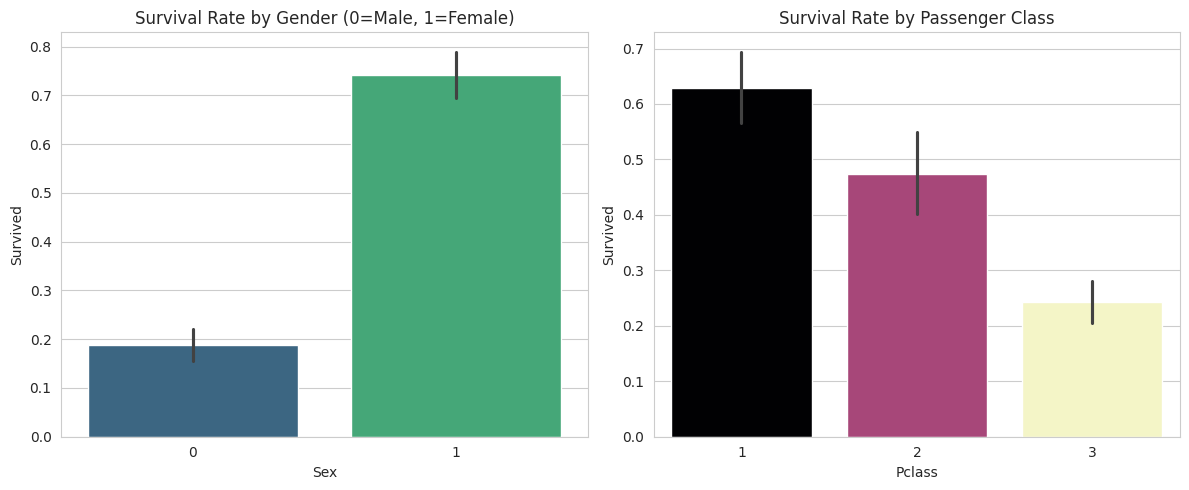

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set aesthetic style
sns.set_style("whitegrid")

# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# Plot 1: Survival by Gender (Fixed with hue)
plt.subplot(1, 2, 1)
sns.barplot(x='Sex', y='Survived', hue='Sex', data=train_df, palette='viridis', legend=False)
plt.title('Survival Rate by Gender (0=Male, 1=Female)')

# Plot 2: Survival by Passenger Class (Fixed with hue)
plt.subplot(1, 2, 2)
sns.barplot(x='Pclass', y='Survived', hue='Pclass', data=train_df, palette='magma', legend=False)
plt.title('Survival Rate by Passenger Class')

plt.tight_layout()
plt.show()

### Step 8: Correlation Analysis
We use a Heatmap to visualize the Pearson correlation coefficients between numerical variables. 
This helps identify which factors have the strongest relationship with **Survival**.

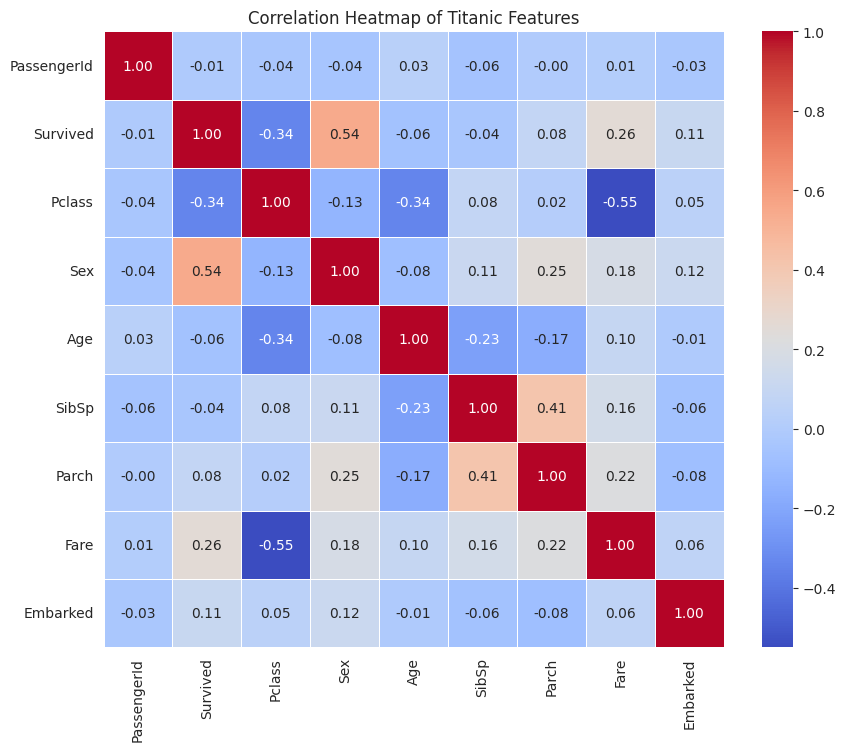

In [68]:
# Compute the correlation matrix
# Note: We only use numeric columns for correlation
corr_matrix = train_df.select_dtypes(include=['number']).corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Titanic Features')
plt.show()

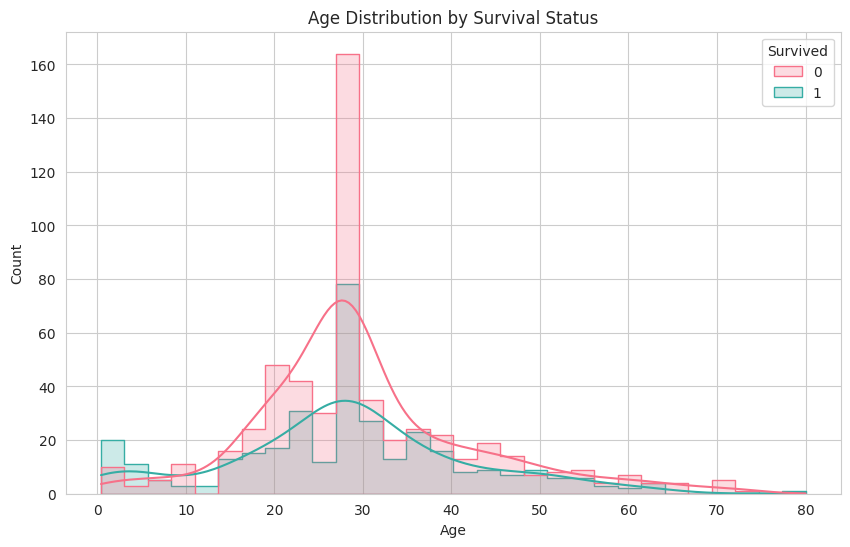

In [69]:
plt.figure(figsize=(10, 6))
sns.histplot(data=train_df, x='Age', hue='Survived', kde=True, element="step", palette='husl')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### Final Insights & Patterns
Based on the EDA, we can conclude the following:

**Gender**: Being female was the strongest predictor of survival (approx. 74% vs 19% for males).

**Class**: Socio-economic status played a major role; 1st-class passengers had a much higher survival rate than 3rd-class passengers.
  
**Age**: Children had a higher survival rate, while the elderly and young adults in 3rd class were more at risk.

 **Fare**: There is a positive correlation between the fare paid and survival, likely linked to passenger class.